Analyse stiener graph RWR probs

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_1samp
%matplotlib inline

In [2]:
rwr_prob = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/depMap_RWR_EGFR_probs.csv', header = 0, index_col=0)
rwr_prob.head()

,rwr_prob_EGFR,gene,EGFR_KEGG,FORGE_HCG,gene_imp,logFC,adj.P.Val,depMap_avg_exp,deg_type,top20_prob
TYMS,0.000054,TYMS,no,no,NaN,-0.006422,0.954032,7.040001,non_significant,non_hcg
ARHGEF5,0.000094,ARHGEF5,no,yes,0.763094,-0.241592,0.495908,1.793664,non_significant,low_rwrProb
CDH20,0.000015,CDH20,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg
LIMS1,0.000015,LIMS1,no,no,NaN,-0.029329,0.713338,6.229401,non_significant,non_hcg
OLIG2,0.000011,OLIG2,no,no,NaN,NaN,NaN,NaN,non_significant,non_hcg


In [3]:
x = rwr_prob['rwr_prob_EGFR'].values

iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
iqr = max(iqr, 1e-8)   # numerical floor

z = (x - np.median(x)) / iqr

rwr_prob['log_scaled_rwr'] = np.sign(z) * np.log10(1 + np.abs(z))


In [4]:
df = rwr_prob.copy()

In [11]:
df['deg_type'].value_counts()

deg_type
non_significant    2210
downregulated       161
upregulated          74
Name: count, dtype: int64

In [12]:
# --- mutually exclusive membership ---
def assign_membership(row):
    
    # Priority 1: FORGE_HCG
    if row['FORGE_HCG'] == 'yes':
        return 'FORGE_HCG'
    
    # Priority 2: KEGG
    elif row['EGFR_KEGG'] == 'yes':
        return 'KEGG'
    
    # Priority 3: DEG (only if not in above)
    elif row['deg_type'] == 'upregulated':
        return 'DEG_up'
    elif row['deg_type'] == 'downregulated':
        return 'DEG_down'
    elif row['deg_type'] == 'non_significant':
        return 'non_significant'
    
    # fallback
    else:
        return 'no_member'

In [13]:
df['membership'] = df.apply(assign_membership, axis=1)

# --- final long df ---
long_df = df[['gene', 'membership', 'log_scaled_rwr']].dropna()

# check counts
print(long_df['membership'].value_counts())

membership
non_significant    2051
FORGE_HCG           138
DEG_down            138
KEGG                 77
DEG_up               41
Name: count, dtype: int64


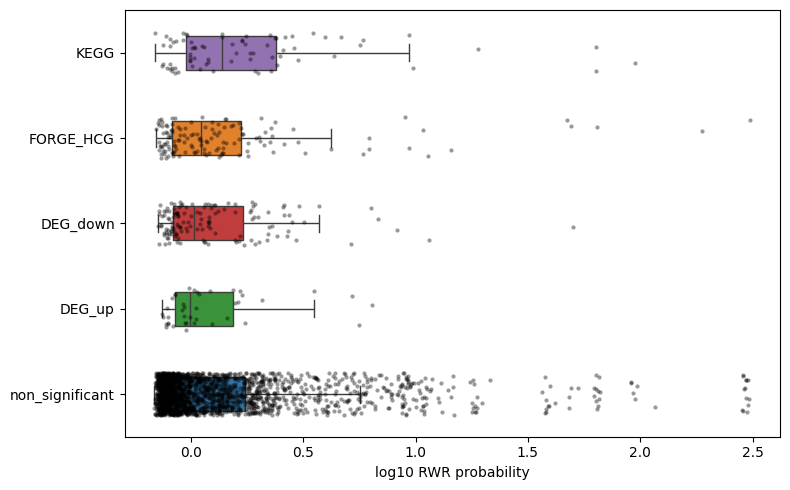

In [17]:
# --- compute order based on median ---
order = (
    long_df.groupby('membership')['log_scaled_rwr']
    .median()
    .sort_values(ascending=False)   # highest median on top
    .index
)

plt.figure(figsize=(8, 5))

# --- horizontal boxplot ---
sns.boxplot(
    data=long_df,
    y='membership',
    x='log_scaled_rwr',
    order=order,
    width=0.4,
    hue='membership', showfliers=False   # hides outlier dots
)

# --- stripplot ---
sns.stripplot(
    data=long_df,
    y='membership',
    x='log_scaled_rwr',
    order=order,
    color='black',
    jitter=0.25,
    alpha=0.4,
    size=3
)

plt.ylabel('')
plt.xlabel('log10 RWR probability')
plt.tight_layout()

# Optional: clean legend (since hue duplicates)
plt.savefig('egfr_rwr_probs_sorted.pdf', dpi=300, bbox_inches='tight')

plt.show()